1-

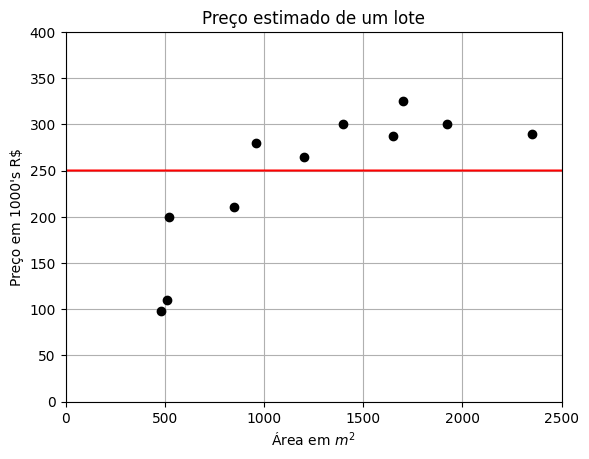

MSE com theta0: 5593.0


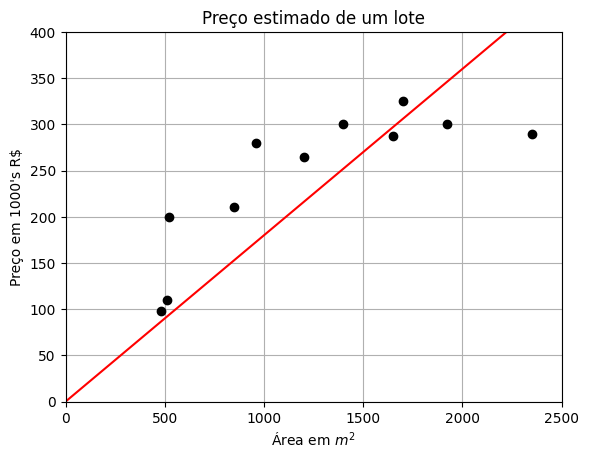

MSE com theta1: 4678.360000000001


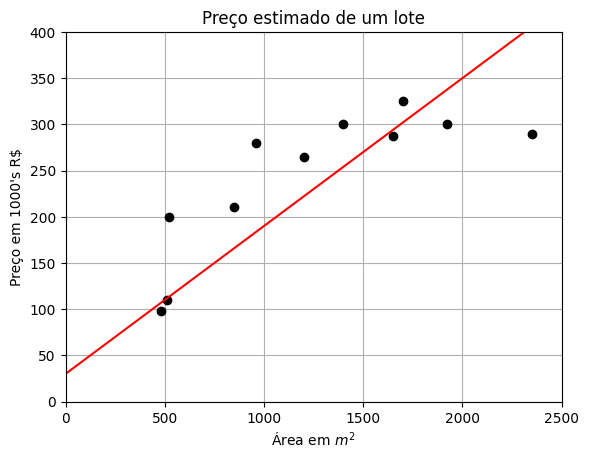

MSE com theta0 e theta1: 37086.53090909091


In [1]:
import matplotlib.pyplot as plt
import numpy as np

#y = mx + b
#b=theta0
#m=theta1

x = np.array([480, 510, 520, 850, 960, 1200, 1400, 1650, 1700, 1920, 2350])
y = np.array([98, 110, 200, 210, 280, 265, 300, 287, 325, 300, 290])

#a) apenas theta0

m1 = 0
b1 = 250

plt.plot(x, y, 'o', color='black')

x_entrada1 = np.linspace(0, 2500, 2500)
y_predito1 = m1 * x_entrada1 + b1

plt.plot(x_entrada1, y_predito1, '-r')
plt.xlim(0, 2500)
plt.ylim(0, 400)

plt.xlabel('Área em $m^2$')
plt.ylabel('Preço em 1000\'s R$')
plt.title('Preço estimado de um lote')
plt.grid()
plt.show()

mse = 0

for i in range (len(x)):
    y_hat = m1*x[i]+b1
    mse += (y[i] - y_hat)**2

mse = mse / len(x)
print(F'MSE com theta0: {mse}')

#b) apenas theta1

m2 = 0.18
b2 = 0

plt.plot(x, y, 'o', color='black')
x_entrada2 = np.linspace(0, 2500, 2500)
y_predito2 = m2 * x_entrada2 + b2

plt.plot(x_entrada2, y_predito2, '-r')
plt.xlim(0, 2500)
plt.ylim(0, 400)
plt.xlabel('Área em $m^2$')
plt.ylabel('Preço em 1000\'s R$')
plt.title('Preço estimado de um lote')
plt.grid()
plt.show()

mse = 0
for i in range(len(x)):
    y_hat = m2*x[i]+b2
    mse += (y[i] - y_hat)**2

mse = mse / len(x)
print(f'MSE com theta1: {mse}')

#c) theta0 e theta1

m3 = 0.16
b3 = 30

plt.plot(x, y, 'o', color='black')
x_entrada3 = np.linspace(0, 2500, 2500)
y_predito3 = m3 * x_entrada3 + b3

plt.plot(x_entrada3, y_predito3, '-r')
plt.xlim(0, 2500)
plt.ylim(0, 400)
plt.xlabel('Área em $m^2$')
plt.ylabel('Preço em 1000\'s R$')
plt.title('Preço estimado de um lote')
plt.grid()
plt.show()

mse = 0
for i in range (len(x)):
    y_hat = y[i] - m3 * x[i] + b3
    mse += (y[i] - y_hat)**2

mse = mse / len(x)
print(f'MSE com theta0 e theta1: {mse}')




2-

In [3]:
def calcula_mse(x, y, m, b):
    mse = 0
    for i in range(len(x)):
        y_hat = m * x[i] + b
        mse += (y[i] - y_hat) ** 2
    return mse / len(x)

MSE com theta0:
MSE mínimo: 5533.363636363636


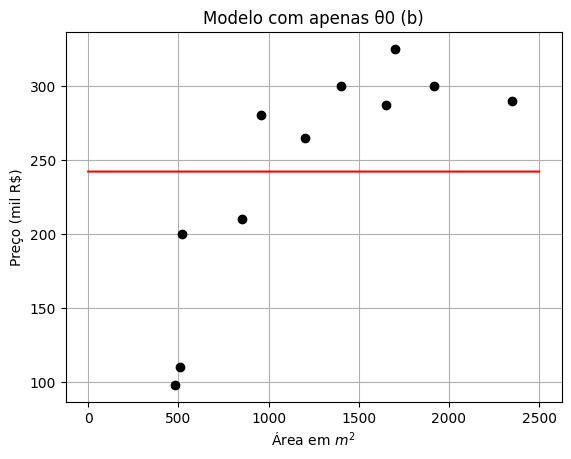

MSE com theta1:
MSE mínimo: 4672.406555522671


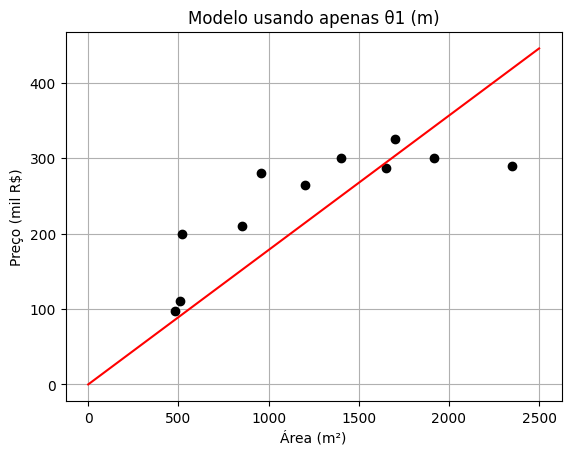

In [5]:
import matplotlib.pyplot as plt
import numpy as np

x = np.array([480, 510, 520, 850, 960, 1200, 1400, 1650, 1700, 1920, 2350])
y = np.array([98, 110, 200, 210, 280, 265, 300, 287, 325, 300, 290])

#a) apenas theta0

m = 0
melhor_b = None
menor_mse_b = float('inf')

for i in range (0, 401):
    mse = calcula_mse(x, y, m, i)

    if mse < menor_mse_b:
        menor_mse_b = mse
        melhor_b = i

print(f'MSE com theta0:')
print(f'MSE mínimo: {menor_mse_b}')

plt.plot(x, y, 'o', color='black')

x_entrada = np.linspace(0, 2500, 2500)
y_predito = m * x_entrada + melhor_b

plt.plot(x_entrada, y_predito, '-r')
plt.xlabel('Área em $m^2$')
plt.ylabel('Preço (mil R$)')
plt.title('Modelo com apenas θ0 (b)')
plt.grid()
plt.show()

#b) apenas theta1

b = 0
melhor_m = None
menor_mse_m = float('inf')

for i in np.linspace(0, 0.5, 1000):

    mse = calcula_mse(x, y, i, b)

    if mse < menor_mse_m:
        menor_mse_m = mse
        melhor_m = i

print(f'MSE com theta1:')
print(f'MSE mínimo: {menor_mse_m}')

plt.plot(x, y, 'o', color='black')

x_entrada = np.linspace(0, 2500, 2500)
y_predito = melhor_m * x_entrada

plt.plot(x_entrada, y_predito, '-r')
plt.xlabel('Área (m²)')
plt.ylabel('Preço (mil R$)')
plt.title('Modelo usando apenas θ1 (m)')
plt.grid()
plt.show()



3 - 

Número máximo de épocas
m final: 0.17806743764355554
b final: 0.22894898448150705
MSE final: 2330.963766916817


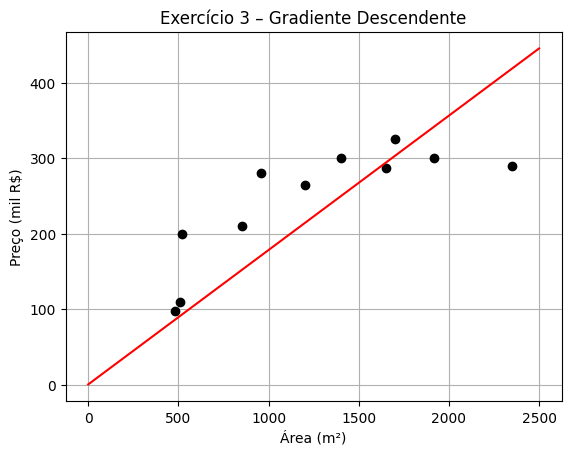

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.array([480, 510, 520, 850, 960, 1200, 1400, 1650, 1700, 1920, 2350]) #escala 10^3
y = np.array([98, 110, 200, 210, 280, 265, 300, 287, 325, 300, 290]) #escala 10^2

m = 0.0
b = 0.0

#ordem de grandeza de x pode chegar a 100000 ao somar tudo e / 11
#então alfa deve ser similar 1e-6
#melhor dorma de escolher alfa e rodar por uma epoca, assim pega ele e faz 0.1/epoca

#erro_min e pela escala do problema em y
#100 até 300
#1, 0.1, 0.01

plt.plot(x, y, 'o', color = 'black')

alfa = 1e-6
epocas = 10000
erro_min = 1e-3
paciencia = 100

melhor_erro = float('inf')
sem_melhora = 0
epoca = 0

while True:

    m1 = 0
    b1 = 0
    erro_tot = 0

    for i in range(len(x)):
        y_hat = m * x[i] + b

        m1 += ((y_hat -y[i]) * x[i])
        b1 += y_hat -y[i]
        erro_tot += (y_hat -y[i])**2
    
    m1 = m1 / len(x)
    b1 = b1 / len(x)
    mse = erro_tot / (2 * len(x))

    m = m - alfa * m1
    b = b - alfa * b1

    if mse < erro_min:
        print("Erro mínimo atingido")
        break
    
    if mse < melhor_erro:
        melhor_erro = mse
        sem_melhora = 0
    else:
        sem_melhora += 1
    
    if sem_melhora >= paciencia:
        print("Erro não melhora mais")
        break

    if epoca >= epocas:
        print("Número máximo de épocas")
        break

    epoca += 1


print(f'm final: {m}')
print(f'b final: {b}')
print(f'MSE final: {mse}')


x_entrada = np.linspace(0, 2500, 2500)
y_predito = m * x_entrada + b

plt.plot(x_entrada, y_predito, '-r')
plt.xlabel('Área (m²)')
plt.ylabel('Preço (mil R$)')
plt.title('Exercício 3 – Gradiente Descendente')
plt.grid()
plt.show()

4 - 

In [5]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

Número máximo de épocas
Theta0: -18.28028667121314
Theta1: 12.074422732796181
Theta2: 12.074422732796181
Perda: 0.0017135254130423991


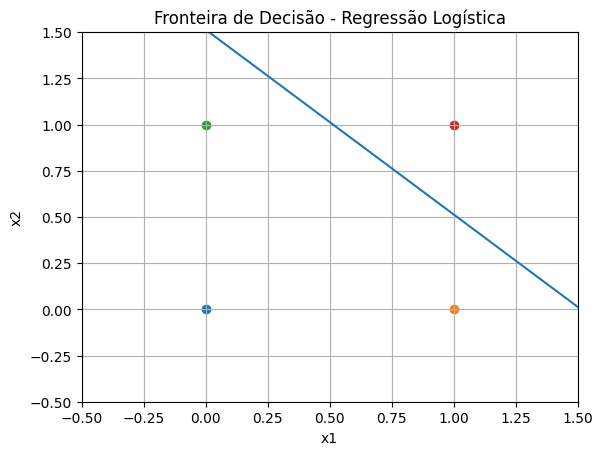

In [13]:
import matplotlib.pyplot as plt
import numpy as np

x1 = np.array([0, 1, 0, 1])
x2 = np.array([0, 0, 1, 1])
y = np.array([0, 0, 0, 1])

theta0 = 0.0
theta1 = 0.0
theta2 = 0.0

alpha = 0.1
epocas = 100000
paciencia = 100

melhor_erro = float('inf')
sem_melhora = 0
epoca = 0

while True:
    t0_grad = 0
    t1_grad = 0
    t2_grad = 0
    erro_tot = 0

    for i in range(len(x1)):

        z = theta0 + theta1*x1[i] + theta2 * x2[i]
        y_hat = sigmoid(z)

        if y_hat < 1e-10:
            y_hat = 1e-10
        elif y_hat > 1 - 1e-10:
            y_hat = 1 - 1e-10
        
        t0_grad += (y_hat -y[i])
        t1_grad += (y_hat -y[i]) * x1[i]
        t2_grad += (y_hat -y[i]) * x2[i]

        erro_tot += -(y[i]*np.log(y_hat) + (1-y[i])*np.log(1-y_hat))
    
    t0_grad /= len(x1)
    t1_grad /= len(x1)
    t2_grad /= len(x1)
    perda = erro_tot / len(x1)

    theta0 -= alpha * t0_grad
    theta1 -= alpha * t1_grad
    theta2 -= alpha * t2_grad

    if perda < melhor_erro:
        melhor_erro = perda
        sem_melhora = 0
    else:
        sem_melhora += 1
    
    if sem_melhora >= paciencia:
        print("Não melhora mais")
        break

    if epoca >= epocas:
        print("Número máximo de épocas")
        break

    epoca += 1

print("Theta0:", theta0)
print("Theta1:", theta1)
print("Theta2:", theta2)
print("Perda:", perda)

plt.figure()

for i in range(len(x1)):
    if y[i] == 0:
        plt.scatter(x1[i], x2[i])
    else:
        plt.scatter(x1[i], x2[i])

x_vals = np.linspace(-0.5, 1.5, 100)

if abs(theta2) > 1e-6:
    y_vals = -(theta0 + theta1*x_vals) / theta2
    plt.plot(x_vals, y_vals)
else:
    if abs(theta1) > 1e-6:
        x_vertical = -theta0 / theta1
        plt.axvline(x=x_vertical)

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Fronteira de Decisão - Regressão Logística")
plt.grid()
plt.show()


5 - 

Número máximo de épocas
Theta0: 0.0243859019693996
Theta1: 0.02461689936893379
Theta2: 0.02461689936893379
Perda: 0.6750819753100122


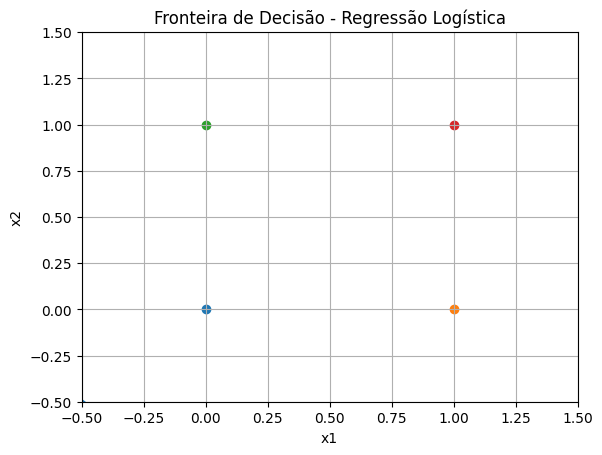

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x1 = np.array([0, 1, 0, 1])
x2 = np.array([0, 0, 1, 1])
y = np.array([0, 1, 1, 1])

theta0 = 0.0
theta1 = 0.0
theta2 = 0.0

alpha = 0.1
epocas = 10000
paciencia = 100

melhor_erro = float('inf')
sem_melhora = 0
epoca = 0

while True:
    t0_grad = 0
    t1_grad = 0
    t2_grad = 0
    erro_tot = 0

    for i in range(len(x1)):

        z = theta0 + theta1*x1[i] + theta2 * x2[i]
        y_hat = sigmoid(z)

        if y_hat < 1e-10:
            y_hat = 1e-10
        elif y_hat > 1 - 1e-10:
            y_hat = 1 - 1e-10
        
        t0_grad += (y_hat -y[i])
        t1_grad += (y_hat -y[i]) * x1[i]
        t2_grad += (y_hat -y[i]) * x2[i]

        erro_tot += -(y[i]*np.log(y_hat) + (1-y[i])*np.log(1-y_hat))
    
    t0_grad /= len(x1)
    t1_grad /= len(x1)
    t2_grad /= len(x1)
    perda = erro_tot / len(x1)

    theta0 -= alpha * t0_grad
    theta1 -= alpha * t1_grad
    theta2 -= alpha * t2_grad

    if perda < melhor_erro:
        melhor_erro = perda
        sem_melhora = 0
    else:
        sem_melhora += 1
    
    if sem_melhora >= paciencia:
        print("Não melhora mais")
        break

    if epoca >= epocas:
        print("Número máximo de épocas")
        break

    epoca += 1

print("Theta0:", theta0)
print("Theta1:", theta1)
print("Theta2:", theta2)
print("Perda:", perda)

plt.figure()

for i in range(len(x1)):
    if y[i] == 0:
        plt.scatter(x1[i], x2[i])
    else:
        plt.scatter(x1[i], x2[i])

x_vals = np.linspace(-0.5, 1.5, 100)

if abs(theta2) > 1e-6:
    y_vals = -(theta0 + theta1*x_vals) / theta2
    plt.plot(x_vals, y_vals)
else:
    if abs(theta1) > 1e-6:
        x_vertical = -theta0 / theta1
        plt.axvline(x=x_vertical)

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Fronteira de Decisão - Regressão Logística")
plt.grid()
plt.show()
